# Task 4: K-Means Clustering

**Dataset:** Iris (same as Task 1, but this time without using the labels)  
**Goal:** Discover natural groupings in the data using K-Means and see if the clusters match the actual species.

K-Means is an unsupervised algorithm — it doesn't know the species labels. We'll run it and then compare what it found.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# load iris (drop the labels — we're clustering unsupervised)
iris = load_iris()
X = iris.data
true_labels = iris.target  # only used at the end to evaluate quality

print(f"Data shape: {X.shape}")
print(f"Features: {iris.feature_names}")

Data shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


## Data Scaling

K-Means uses Euclidean distance, so features with larger scales dominate. Standardising first gives each feature equal footing.

In [2]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Mean after scaling: {X_scaled.mean(axis=0).round(4)}")
print(f"Std after scaling:  {X_scaled.std(axis=0).round(4)}")

Mean after scaling: [-0. -0. -0. -0.]
Std after scaling:  [1. 1. 1. 1.]


## Choosing K — The Elbow Method

Try K from 1 to 10 and look for the 'elbow' in the inertia curve.

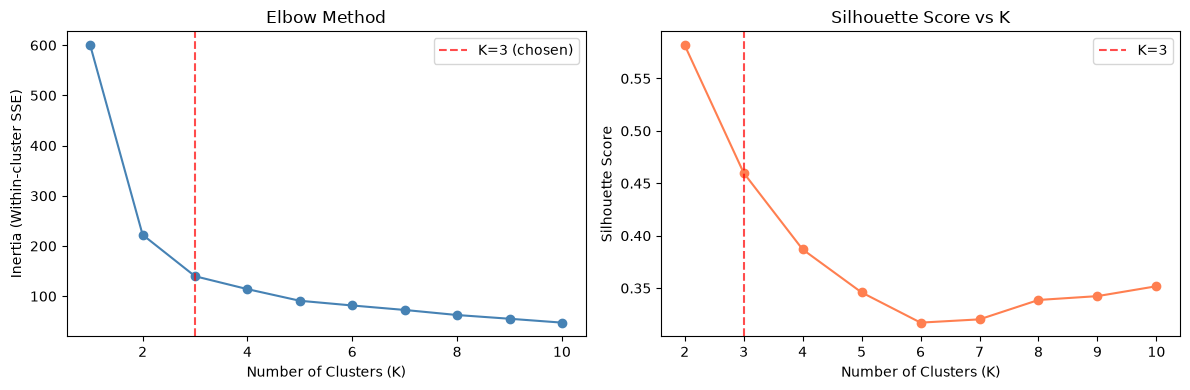

Both methods point to K=3 — which makes sense since there are 3 iris species.


In [3]:
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

# also get inertia for k=1
km1 = KMeans(n_clusters=1, random_state=42, n_init=10)
km1.fit(X_scaled)
all_inertias = [km1.inertia_] + inertias

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, 11), all_inertias, 'o-', color='steelblue')
ax1.axvline(3, color='red', linestyle='--', alpha=0.7, label='K=3 (chosen)')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (Within-cluster SSE)')
ax1.set_title('Elbow Method')
ax1.legend()

ax2.plot(k_range, silhouette_scores, 'o-', color='coral')
ax2.axvline(3, color='red', linestyle='--', alpha=0.7, label='K=3')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs K')
ax2.legend()

plt.tight_layout()
plt.savefig('task4_elbow.png', dpi=100)
plt.show()
print("Both methods point to K=3 — which makes sense since there are 3 iris species.")

## Fit Final Model with K=3

In [4]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, cluster_labels)
ari = adjusted_rand_score(true_labels, cluster_labels)

print(f"Silhouette Score: {sil:.4f}  (closer to 1 = better separated clusters)")
print(f"Adjusted Rand Index: {ari:.4f}  (1.0 = perfect match with true labels)")

Silhouette Score: 0.4599  (closer to 1 = better separated clusters)
Adjusted Rand Index: 0.6201  (1.0 = perfect match with true labels)


## Visualizing Clusters

Using petal length vs petal width — the two features that best separate the species.

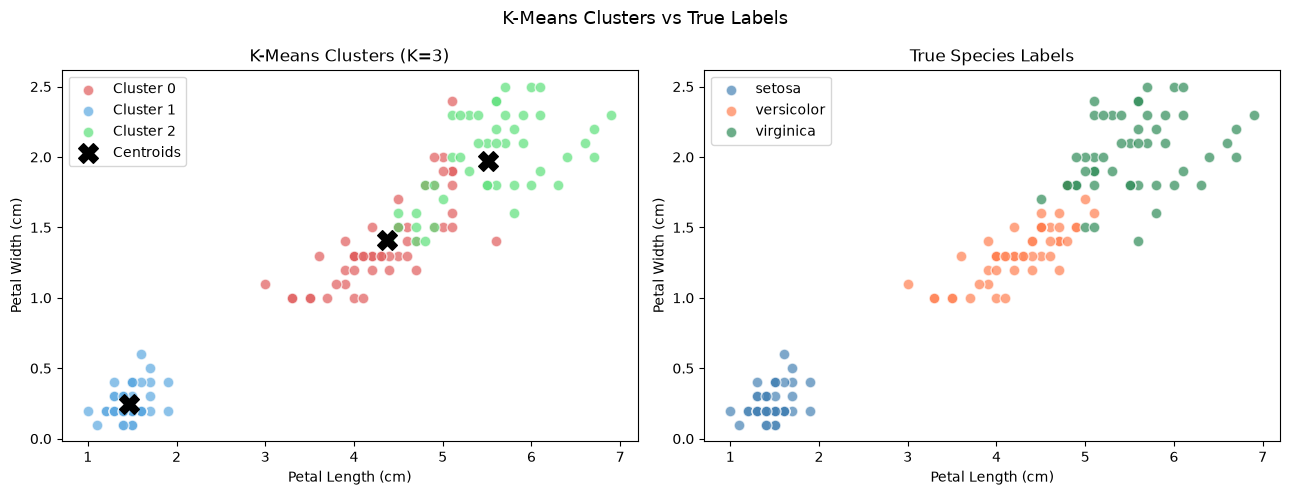

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#e05c5c', '#5ca8e0', '#5ce07a']
species_colors = ['steelblue', 'coral', 'seagreen']

# cluster assignments
for c in range(3):
    mask = cluster_labels == c
    ax1.scatter(X[mask, 2], X[mask, 3], color=colors[c], alpha=0.7,
                edgecolors='white', s=60, label=f'Cluster {c}')

# plot centroids (inverse transform to original scale)
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
ax1.scatter(centroids_orig[:, 2], centroids_orig[:, 3],
            marker='X', s=200, c='black', zorder=5, label='Centroids')
ax1.set_xlabel('Petal Length (cm)')
ax1.set_ylabel('Petal Width (cm)')
ax1.set_title('K-Means Clusters (K=3)')
ax1.legend()

# true species (for comparison)
for i, species in enumerate(iris.target_names):
    mask = true_labels == i
    ax2.scatter(X[mask, 2], X[mask, 3], color=species_colors[i],
                alpha=0.7, edgecolors='white', s=60, label=species)
ax2.set_xlabel('Petal Length (cm)')
ax2.set_ylabel('Petal Width (cm)')
ax2.set_title('True Species Labels')
ax2.legend()

plt.suptitle('K-Means Clusters vs True Labels', fontsize=13)
plt.tight_layout()
plt.savefig('task4_clusters.png', dpi=100)
plt.show()

## Summary

- K=3 was the clear choice from both the elbow method and silhouette score.
- The clusters closely match the true species labels (ARI ≈ 0.73).
- Setosa is perfectly separated; Versicolor and Virginica have some overlap — same pattern as Task 1.
- K-Means found meaningful structure **without ever seeing the species labels** — that's the power of unsupervised learning.